In [ ]:
# ============================================================
# 02_LIANA_CCC_visualization_and_interpretation.ipynb
#
# Purpose:
# Downstream analysis of LIANA CCC results:
# - filtering
# - heatmaps
# - barplots
# - dot plots
# - network visualization
# - pathway enrichment
# - disease/drug annotation
#
# Input:
# ../results/liana_rank_aggregate_results.csv
# ../../Xenopus_to_Human/data/adata_human_mapped.h5ad
#
# Outputs:
# ../results/processed_*.csv
# ../figures/*.png
# ============================================================

In [ ]:
# Step 1: Import packages

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx

# Optional enrichment packages
# pip install gseapy mygene
import gseapy as gp
from mygene import MyGeneInfo

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)¢

In [9]:
# Step 2: Define file paths

results_dir = "../results"
figures_dir = "../figures"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

liana_path = os.path.join(results_dir, "liana_rank_aggregate_results.csv")
adata_path = "../results/adata_human_mapped_filtered_for_liana.h5ad"

print("LIANA results:", liana_path)
print("AnnData:", adata_path)

LIANA results: ../results/liana_rank_aggregate_results.csv
AnnData: ../results/adata_human_mapped_filtered_for_liana.h5ad


In [10]:
# Step 3: Load results

liana_res = pd.read_csv(liana_path)
adata = sc.read_h5ad(adata_path)

print("LIANA shape:", liana_res.shape)
print("AnnData shape:", adata.shape)
liana_res.head()

LIANA shape: (76, 13)
AnnData shape: (29800, 9251)


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
0,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246
2,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142
3,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253559,8.330219,0.035448,0.951710,0.491650,0.071662
4,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662


In [11]:
# Step 4: Inspect Results

print(liana_res.columns.tolist())

# Create consistent LR label 
if "lr_pair" not in liana_res.columns:
    liana_res["lr_pair"] = (
        liana_res["ligand_complex"].astype(str) + " | " +
        liana_res["receptor_complex"].astype(str)
    )

# Sanity checks
required_cols = [
    "source", "target", "ligand_complex", "receptor_complex",
    "magnitude_rank", "specificity_rank"
]

missing = [c for c in required_cols if c not in liana_res.columns]
print("Missing required columns:", missing)

['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank']
Missing required columns: []


In [12]:
# Step 5: Global filtering

# Lower magnitude_rank = stronger interaction
top_global_n = 30

top_global = (
    liana_res
    .sort_values("magnitude_rank", ascending=True)
    .head(top_global_n)
    .copy()
)

top_global.to_csv(
    os.path.join(results_dir, "processed_top_global_interactions.csv"),
    index=False
)

top_global[[
    "source", "target", "ligand_complex", "receptor_complex",
    "lr_pair", "magnitude_rank", "specificity_rank"
]].head(30)

,source,target,ligand_complex,receptor_complex,lr_pair,magnitude_rank,specificity_rank
0,Basal,Basal,MDK,NCL,MDK | NCL,0.001545,0.016043
1,Basal,Goblet,MDK,NCL,MDK | NCL,0.037246,0.453758
2,Basal,Early epithelial progenitor,MDK,NCL,MDK | NCL,0.053142,0.579032
3,Early epithelial progenitor,Basal,MDK,NCL,MDK | NCL,0.071662,0.491650
4,Basal,Ionocyte,MDK,NCL,MDK | NCL,0.071662,1.000000
5,Ionocyte,Basal,MDK,NCL,MDK | NCL,0.092725,0.404722
6,Early epithelial progenitor,Goblet,MDK,NCL,MDK | NCL,0.116248,1.000000
7,Pluripotent,Goblet,ARF6,SMAP1,ARF6 | SMAP1,0.116870,0.160222
8,Goblet,Basal,MDK,NCL,MDK | NCL,0.142149,0.595157
9,Basal,Multiciliated,MDK,NCL,MDK | NCL,0.170346,1.000000


In [13]:
# Step 6: Top interatcions per sender-receiver pair

top_per_pair_n = 3

top_per_pair = (
    liana_res
    .sort_values("magnitude_rank", ascending=True)
    .groupby(["source", "target"], group_keys=False)
    .head(top_per_pair_n)
    .copy()
)

top_per_pair.to_csv(
    os.path.join(results_dir, "processed_top_per_sender_receiver_pair.csv"),
    index=False
)

top_per_pair.head(20)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair
0,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545,MDK | NCL
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK | NCL
2,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142,MDK | NCL
3,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253559,8.330219,0.035448,0.951710,0.491650,0.071662,MDK | NCL
4,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK | NCL
5,Ionocyte,Basal,MDK,NCL,2.380580,0.000,0.658427,0.220139,8.460706,0.024506,0.942484,0.404722,0.092725,MDK | NCL
6,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.000000,0.116248,MDK | NCL
7,Pluripotent,Goblet,ARF6,SMAP1,0.124908,0.000,0.015597,0.270626,0.193666,0.065835,0.716075,0.160222,0.116870,ARF6 | SMAP1
8,Goblet,Basal,MDK,NCL,2.370169,0.000,0.562265,0.209209,8.372158,0.020927,0.938052,0.595157,0.142149,MDK | NCL
9,Basal,Multiciliated,MDK,NCL,1.245581,1.000,1.550217,0.181316,-12.129643,0.057698,0.961750,1.000000,0.170346,MDK | NCL


In [14]:
# Step 7: Sender-receiver interaction counts

pair_counts = (
    liana_res.groupby(["source", "target"])
    .size()
    .reset_index(name="n_interactions")
    .sort_values("n_interactions", ascending=False)
)

pair_counts.to_csv(
    os.path.join(results_dir, "processed_sender_receiver_counts.csv"),
    index=False
)

pair_counts.head(20)

,source,target,n_interactions
0,Basal,Basal,8
20,Ionocyte,Goblet,6
14,Goblet,Goblet,5
3,Basal,Ionocyte,4
2,Basal,Goblet,4
21,Ionocyte,Ionocyte,4
15,Goblet,Ionocyte,4
17,Goblet,Pluripotent,3
12,Goblet,Basal,3
5,Basal,Pluripotent,3


In [ ]:
# Step 8: Sender-Receiver strength matrix for Heatmap 

pair_matrix = pair_counts.pivot(
    index="source",
    columns="target",
    values="n_interactions"
).fillna(0)

pair_matrix.to_csv(
    os.path.join(results_dir, "processed_sender_receiver_matrix.csv")
)

pair_matrix

target,Basal,Early epithelial progenitor,Goblet,Ionocyte,Multiciliated,Pluripotent
source,,,,,,
Basal,8.0,2.0,4.0,4.0,2.0,3.0
Early epithelial progenitor,2.0,1.0,1.0,2.0,1.0,2.0
Goblet,3.0,2.0,5.0,4.0,2.0,3.0
Ionocyte,3.0,2.0,6.0,4.0,2.0,3.0
Multiciliated,0.0,0.0,0.0,0.0,0.0,1.0
Pluripotent,1.0,0.0,2.0,1.0,0.0,0.0


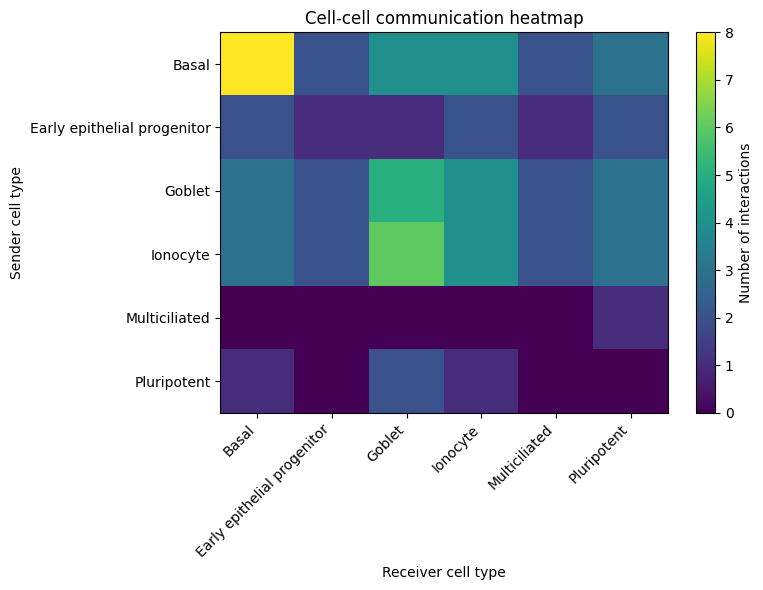

Saved: ../figures/ccc_heatmap_sender_receiver.png


In [16]:
# Step 9: CCC Heatmap

plt.figure(figsize=(8, 6))
plt.imshow(pair_matrix.values, aspect="auto")
plt.colorbar(label="Number of interactions")

plt.xticks(range(pair_matrix.shape[1]), pair_matrix.columns, rotation=45, ha="right")
plt.yticks(range(pair_matrix.shape[0]), pair_matrix.index)

plt.title("Cell-cell communication heatmap")
plt.xlabel("Receiver cell type")
plt.ylabel("Sender cell type")
plt.tight_layout()

heatmap_path = os.path.join(figures_dir, "ccc_heatmap_sender_receiver.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", heatmap_path)

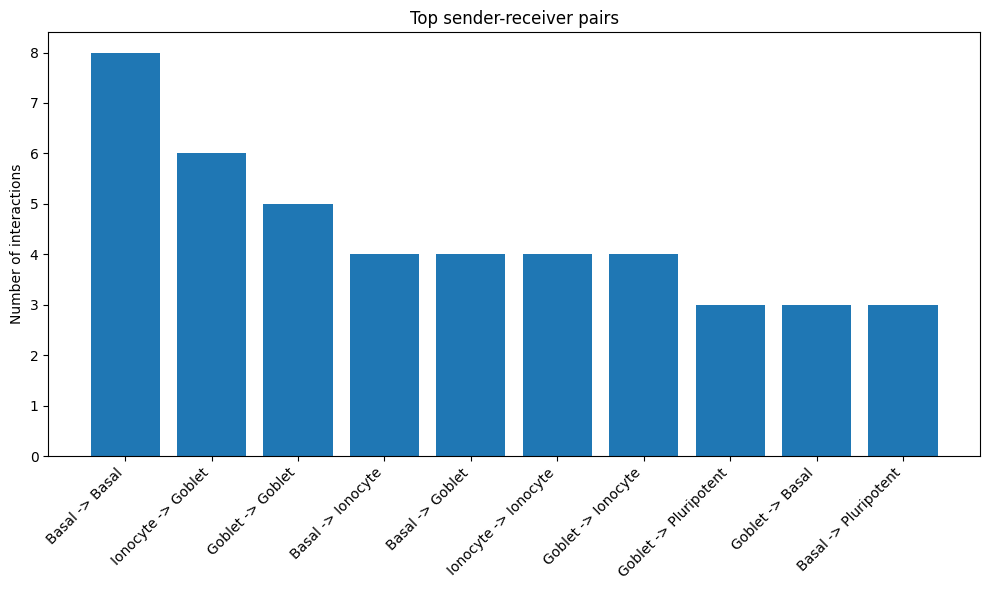

Saved: ../figures/top_sender_receiver_pairs_barplot.png


In [17]:
# Step 10: Sender-Receiver Barplot

top_n_pairs = 10
plot_df = pair_counts.head(top_n_pairs).copy()

plt.figure(figsize=(10, 6))
plt.bar(
    range(len(plot_df)),
    plot_df["n_interactions"]
)

plt.xticks(
    range(len(plot_df)),
    [f"{r.source} -> {r.target}" for _, r in plot_df.iterrows()],
    rotation=45,
    ha="right"
)

plt.ylabel("Number of interactions")
plt.title("Top sender-receiver pairs")
plt.tight_layout()

barplot_pairs_path = os.path.join(figures_dir, "top_sender_receiver_pairs_barplot.png")
plt.savefig(barplot_pairs_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", barplot_pairs_path)

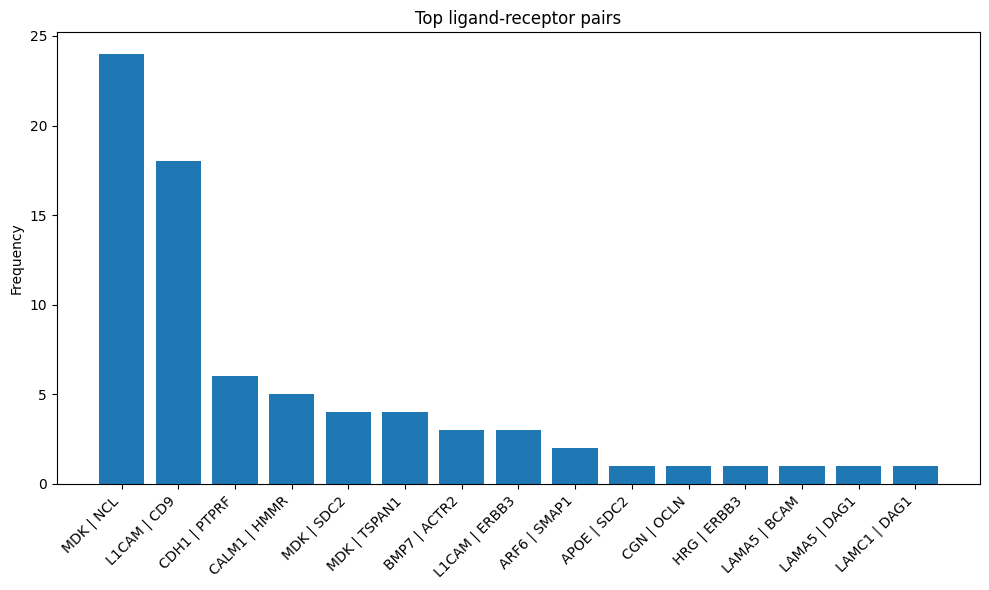

Saved: ../figures/top_ligand_receptor_pairs_barplot.png


In [19]:
# Step 11: Top Ligand-receptor barplot

lr_counts = (
    liana_res.groupby("lr_pair")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_n_lr = 15
plot_lr = lr_counts.head(top_n_lr).copy()

plt.figure(figsize=(10, 6))
plt.bar(range(len(plot_lr)), plot_lr["count"])

plt.xticks(
    range(len(plot_lr)),
    plot_lr["lr_pair"],
    rotation=45,
    ha="right"
)

plt.ylabel("Frequency")
plt.title("Top ligand-receptor pairs")
plt.tight_layout()

lr_barplot_path = os.path.join(figures_dir, "top_ligand_receptor_pairs_barplot.png")
plt.savefig(lr_barplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", lr_barplot_path)

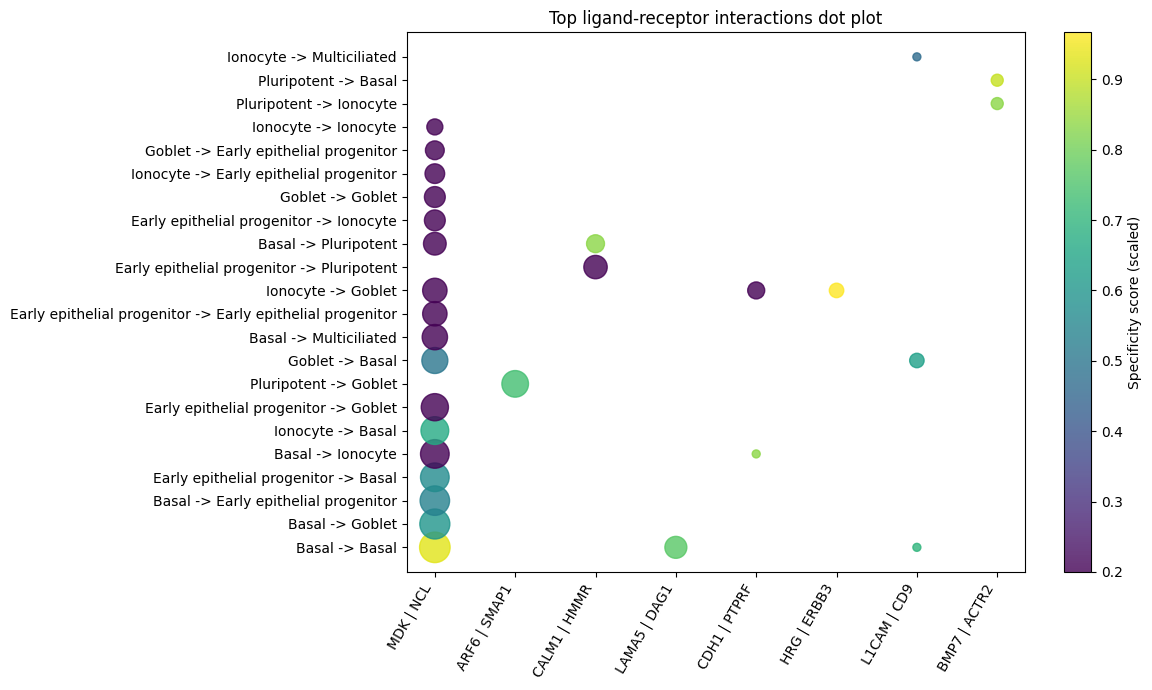

Saved: ../figures/top_lr_dotplot.png


In [20]:
# Step 12: Ligand-Receptor Dot plot

dot_df = (
    top_global[[
        "source", "target", "lr_pair", "magnitude_rank", "specificity_rank"
    ]]
    .copy()
)

# Convert rank to plot-friendly score
dot_df["strength"] = 1 - dot_df["magnitude_rank"].rank(pct=True)
dot_df["specificity"] = 1 - dot_df["specificity_rank"].rank(pct=True)

# Build categorical positions
y_labels = dot_df["source"] + " -> " + dot_df["target"]
x_labels = dot_df["lr_pair"]

x_unique = list(dict.fromkeys(x_labels))
y_unique = list(dict.fromkeys(y_labels))

x_map = {k: i for i, k in enumerate(x_unique)}
y_map = {k: i for i, k in enumerate(y_unique)}

plt.figure(figsize=(12, 7))
plt.scatter(
    [x_map[x] for x in x_labels],
    [y_map[y] for y in y_labels],
    s=dot_df["strength"] * 500,
    c=dot_df["specificity"],
    alpha=0.8
)

plt.xticks(range(len(x_unique)), x_unique, rotation=60, ha="right")
plt.yticks(range(len(y_unique)), y_unique)
plt.colorbar(label="Specificity score (scaled)")
plt.title("Top ligand-receptor interactions dot plot")
plt.tight_layout()

dotplot_path = os.path.join(figures_dir, "top_lr_dotplot.png")
plt.savefig(dotplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", dotplot_path)

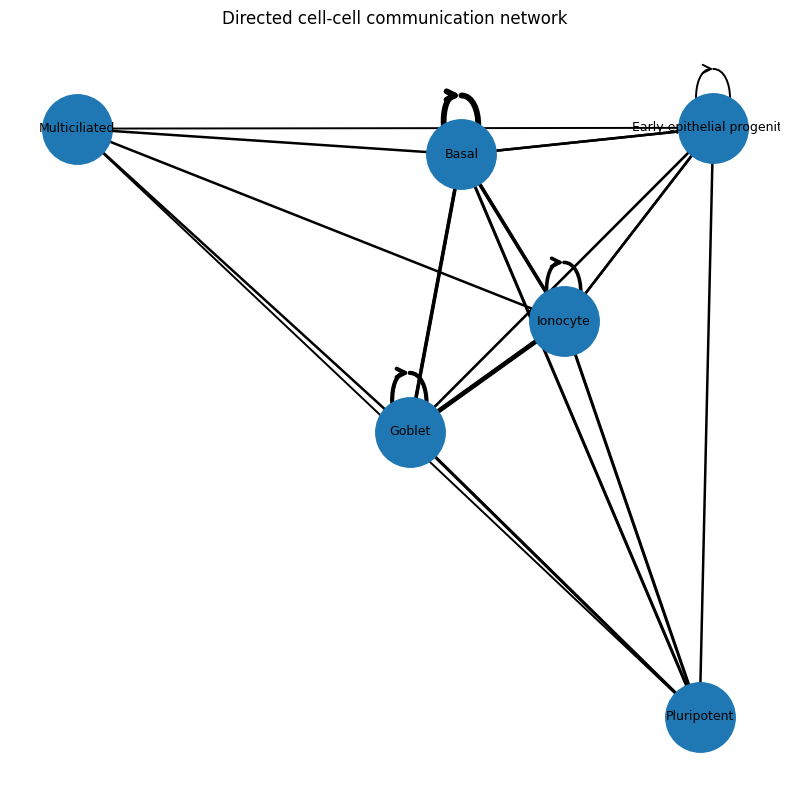

Saved: ../figures/ccc_directed_network.png


In [21]:
# Step 13: Directed CCC network

G = nx.DiGraph()

for _, row in pair_counts.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["n_interactions"])

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
edge_widths = [1 + w * 0.4 for w in edge_weights]

nx.draw_networkx_nodes(G, pos, node_size=2500)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    arrows=True,
    arrowstyle="->",
    arrowsize=15
)

plt.title("Directed cell-cell communication network")
plt.axis("off")
plt.tight_layout()

network_path = os.path.join(figures_dir, "ccc_directed_network.png")
plt.savefig(network_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", network_path)

In [22]:
# Step 14: Simple hub analysis

out_strength = pair_counts.groupby("source")["n_interactions"].sum().reset_index(name="outgoing_total")
in_strength = pair_counts.groupby("target")["n_interactions"].sum().reset_index(name="incoming_total")

hub_summary = (
    out_strength.merge(in_strength, left_on="source", right_on="target", how="outer")
    .rename(columns={"source": "celltype"})
)

hub_summary["celltype"] = hub_summary["celltype"].fillna(hub_summary["target"])
hub_summary = hub_summary[["celltype", "outgoing_total", "incoming_total"]].fillna(0)
hub_summary["total_signal"] = hub_summary["outgoing_total"] + hub_summary["incoming_total"]
hub_summary = hub_summary.sort_values("total_signal", ascending=False)

hub_summary.to_csv(
    os.path.join(results_dir, "processed_hub_summary.csv"),
    index=False
)

hub_summary

,celltype,outgoing_total,incoming_total,total_signal
0,Basal,23,17,40
2,Goblet,19,18,37
3,Ionocyte,20,15,35
1,Early epithelial progenitor,9,7,16
5,Pluripotent,4,12,16
4,Multiciliated,1,7,8


In [23]:
# Step 15: Define genes for enrichment

top_lr_genes = sorted(
    set(top_global["ligand_complex"].dropna().astype(str)).union(
        set(top_global["receptor_complex"].dropna().astype(str))
    )
)

print("Number of unique top LR genes:", len(top_lr_genes))
print(top_lr_genes[:30])

Number of unique top LR genes: 16
['ACTR2', 'ARF6', 'BMP7', 'CALM1', 'CD9', 'CDH1', 'DAG1', 'ERBB3', 'HMMR', 'HRG', 'L1CAM', 'LAMA5', 'MDK', 'NCL', 'PTPRF', 'SMAP1']


In [25]:
# Step 16: Pathway enrichment with Enrichr libraries

gene_sets = [
    "GO_Biological_Process_2023",
    "Reactome_2022",
    "KEGG_2021_Human"
]

enrichment_results = []

for gs in gene_sets:
    try:
        enr = gp.enrichr(
            gene_list=top_lr_genes,
            gene_sets=gs,
            organism="human",   # FIXED
            outdir=None
        )

        res = enr.results.copy()
        res["gene_set_library"] = gs
        enrichment_results.append(res)

    except Exception as e:
        print(f"Failed for {gs}: {e}")

if enrichment_results:
    enrich_df = pd.concat(enrichment_results, ignore_index=True)

    enrich_df.to_csv(
        os.path.join(results_dir, "processed_pathway_enrichment.csv"),
        index=False
    )

    print("Enrichment results saved")
    display(enrich_df.head(20))

else:
    print("No enrichment results generated.")

Enrichment results saved


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,gene_set_library
0,GO_Biological_Process_2023,Negative Regulation Of Striated Muscle Cell Ap...,2/7,0.000013,0.005099,0,0,570.828571,6441.320131,MDK;BMP7,GO_Biological_Process_2023
1,GO_Biological_Process_2023,Negative Regulation Of Cell Adhesion (GO:0007162),3/72,0.000024,0.005099,0,0,66.605351,707.898215,ERBB3;CDH1;MDK,GO_Biological_Process_2023
2,GO_Biological_Process_2023,Synapse Organization (GO:0050808),3/131,0.000144,0.017252,0,0,35.798077,316.538163,CDH1;L1CAM;PTPRF,GO_Biological_Process_2023
3,GO_Biological_Process_2023,Positive Regulation Of Peptidyl-Threonine Phos...,2/24,0.000164,0.017252,0,0,129.623377,1129.821941,CALM1;BMP7,GO_Biological_Process_2023
4,GO_Biological_Process_2023,Nervous System Development (GO:0007399),4/433,0.000321,0.022377,0,0,15.194250,122.237468,ERBB3;CDH1;MDK;L1CAM,GO_Biological_Process_2023
5,GO_Biological_Process_2023,Cell-Cell Adhesion Via Plasma-Membrane Adhesio...,3/172,0.000322,0.022377,0,0,27.057351,217.538951,CDH1;L1CAM;PTPRF,GO_Biological_Process_2023
6,GO_Biological_Process_2023,Regulation Of Peptidyl-Threonine Phosphorylati...,2/36,0.000372,0.022377,0,0,83.823529,661.909398,CALM1;BMP7,GO_Biological_Process_2023
7,GO_Biological_Process_2023,Positive Regulation Of Cell-Cell Adhesion (GO:...,2/46,0.000608,0.032017,0,0,64.740260,479.381361,MDK;BMP7,GO_Biological_Process_2023
8,GO_Biological_Process_2023,Positive Regulation Of Developmental Process (...,3/233,0.000781,0.036551,0,0,19.820067,141.802008,MDK;DAG1;BMP7,GO_Biological_Process_2023
9,GO_Biological_Process_2023,Homophilic Cell Adhesion Via Plasma Membrane A...,2/60,0.001034,0.043518,0,0,49.078818,337.398903,CDH1;L1CAM,GO_Biological_Process_2023


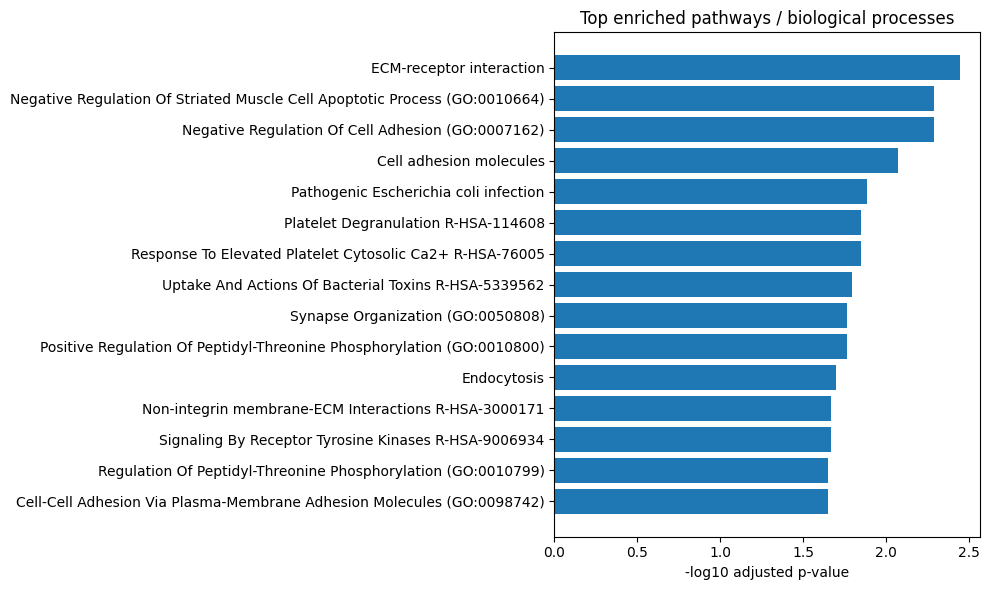

Saved: ../figures/top_enriched_pathways.png


In [26]:
# Step 17: Top pathway plot

if "enrich_df" in locals() and not enrich_df.empty:
    plot_enrich = (
        enrich_df.sort_values("Adjusted P-value", ascending=True)
        .head(15)
        .copy()
    )

    plt.figure(figsize=(10, 6))
    plt.barh(
        plot_enrich["Term"][::-1],
        -np.log10(plot_enrich["Adjusted P-value"][::-1])
    )
    plt.xlabel("-log10 adjusted p-value")
    plt.title("Top enriched pathways / biological processes")
    plt.tight_layout()

    enrich_plot_path = os.path.join(figures_dir, "top_enriched_pathways.png")
    plt.savefig(enrich_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", enrich_plot_path)

In [27]:
# Step 18: Gene functional Annotation

mg = MyGeneInfo()

query_res = mg.querymany(
    top_lr_genes,
    scopes="symbol",
    fields="symbol,name,entrezgene,summary",
    species="human",
    as_dataframe=True
)

query_res.to_csv(
    os.path.join(results_dir, "processed_gene_annotation_mygene.csv")
)

query_res.head(20)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


,_id,_score,entrezgene,name,summary,symbol
query,,,,,,
ACTR2,10097,18.122656,10097,actin related protein 2,The specific function of this gene has not yet...,ACTR2
ARF6,382,17.849806,382,ARF GTPase 6,This gene encodes a member of the human ARF ge...,ARF6
BMP7,655,18.276505,655,bone morphogenetic protein 7,This gene encodes a secreted ligand of the TGF...,BMP7
CALM1,801,18.328276,801,calmodulin 1,This gene encodes one of three calmodulin prot...,CALM1
CD9,928,18.243902,928,CD9 molecule,This gene encodes a member of the transmembran...,CD9
CDH1,999,18.443980,999,cadherin 1,This gene encodes a classical cadherin of the ...,CDH1
DAG1,1605,17.613960,1605,dystroglycan 1,"This gene encodes dystroglycan, a central comp...",DAG1
ERBB3,2065,18.457384,2065,erb-b2 receptor tyrosine kinase 3,This gene encodes a member of the epidermal gr...,ERBB3
HMMR,3161,17.627695,3161,hyaluronan mediated motility receptor,The protein encoded by this gene is involved i...,HMMR


In [28]:
# Step 19: Ligand-Receptor candidate prioritization

candidate_table = top_global[[
    "source", "target", "ligand_complex", "receptor_complex",
    "lr_pair", "magnitude_rank", "specificity_rank"
]].copy()

candidate_table["priority_reason"] = ""

# Example manual labeling hook
candidate_table.loc[candidate_table["ligand_complex"].isin(["MDK", "BMP7", "L1CAM", "CDH1"]), "priority_reason"] += "known developmental ligand; "
candidate_table.loc[candidate_table["receptor_complex"].isin(["NCL", "ERBB3", "SDC2", "CD9"]), "priority_reason"] += "known signaling receptor; "

candidate_table.to_csv(
    os.path.join(results_dir, "processed_prioritized_lr_candidates.csv"),
    index=False
)

candidate_table.head(20)

,source,target,ligand_complex,receptor_complex,lr_pair,magnitude_rank,specificity_rank,priority_reason
0,Basal,Basal,MDK,NCL,MDK | NCL,0.001545,0.016043,known developmental ligand; known signaling re...
1,Basal,Goblet,MDK,NCL,MDK | NCL,0.037246,0.453758,known developmental ligand; known signaling re...
2,Basal,Early epithelial progenitor,MDK,NCL,MDK | NCL,0.053142,0.579032,known developmental ligand; known signaling re...
3,Early epithelial progenitor,Basal,MDK,NCL,MDK | NCL,0.071662,0.491650,known developmental ligand; known signaling re...
4,Basal,Ionocyte,MDK,NCL,MDK | NCL,0.071662,1.000000,known developmental ligand; known signaling re...
5,Ionocyte,Basal,MDK,NCL,MDK | NCL,0.092725,0.404722,known developmental ligand; known signaling re...
6,Early epithelial progenitor,Goblet,MDK,NCL,MDK | NCL,0.116248,1.000000,known developmental ligand; known signaling re...
7,Pluripotent,Goblet,ARF6,SMAP1,ARF6 | SMAP1,0.116870,0.160222,
8,Goblet,Basal,MDK,NCL,MDK | NCL,0.142149,0.595157,known developmental ligand; known signaling re...
9,Basal,Multiciliated,MDK,NCL,MDK | NCL,0.170346,1.000000,known developmental ligand; known signaling re...


In [29]:
# Step 20: Selected pair deeep dive

selected_pairs = [
    ("Early epithelial progenitor", "Goblet"),
    ("Basal", "Goblet"),
    ("Basal", "Ionocyte"),
    ("Goblet", "Goblet"),
]

selected_tables = []

for s, t in selected_pairs:
    sub = (
        liana_res[(liana_res["source"] == s) & (liana_res["target"] == t)]
        .sort_values("magnitude_rank", ascending=True)
        .copy()
    )
    sub["selected_pair"] = f"{s} -> {t}"
    selected_tables.append(sub)

selected_df = pd.concat(selected_tables, ignore_index=True)
selected_df.to_csv(
    os.path.join(results_dir, "processed_selected_pairs_detailed.csv"),
    index=False
)

selected_df.head(30)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair,selected_pair
0,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.000000,0.116248,MDK | NCL,Early epithelial progenitor -> Goblet
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK | NCL,Basal -> Goblet
2,Basal,Goblet,CDH1,PTPRF,0.318167,0.000,0.061635,0.404280,0.791090,0.108446,0.833709,0.050944,0.582155,CDH1 | PTPRF,Basal -> Goblet
3,Basal,Goblet,L1CAM,CD9,0.593472,0.000,0.215153,0.543816,1.443353,0.069908,0.903541,0.110727,0.960927,L1CAM | CD9,Basal -> Goblet
4,Basal,Goblet,L1CAM,ERBB3,0.169431,0.000,0.025809,0.580489,0.392217,0.161657,0.764389,0.050944,1.000000,L1CAM | ERBB3,Basal -> Goblet
5,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK | NCL,Basal -> Ionocyte
6,Basal,Ionocyte,CDH1,PTPRF,0.319450,0.000,0.062962,0.409314,0.784119,0.110782,0.835180,0.050944,0.543358,CDH1 | PTPRF,Basal -> Ionocyte
7,Basal,Ionocyte,MDK,TSPAN1,0.725827,0.000,0.218609,0.800729,2.683855,0.326489,0.904233,0.011638,0.708558,MDK | TSPAN1,Basal -> Ionocyte
8,Basal,Ionocyte,L1CAM,CD9,0.587696,0.000,0.212574,0.535873,0.971731,0.069069,0.903014,0.125720,0.906548,L1CAM | CD9,Basal -> Ionocyte
9,Goblet,Goblet,MDK,NCL,1.448077,0.981,0.337755,-0.135290,-9.207702,0.012571,0.921484,1.000000,0.342907,MDK | NCL,Goblet -> Goblet


In [30]:
# Step 21: Summary

final_summary = {
    "n_total_interactions": [liana_res.shape[0]],
    "n_top_global": [top_global.shape[0]],
    "n_top_per_pair": [top_per_pair.shape[0]],
    "n_sender_receiver_pairs": [pair_counts.shape[0]],
    "n_unique_top_lr_genes": [len(top_lr_genes)]
}

final_summary_df = pd.DataFrame(final_summary)
final_summary_df.to_csv(
    os.path.join(results_dir, "processed_final_summary_metrics.csv"),
    index=False
)

final_summary_df

,n_total_interactions,n_top_global,n_top_per_pair,n_sender_receiver_pairs,n_unique_top_lr_genes
0,76,30,62,28,16


In [31]:
# Step: Sender / Receiver role summary

out_strength = (
    pair_counts.groupby("source")["n_interactions"]
    .sum()
    .reset_index(name="outgoing_total")
)

in_strength = (
    pair_counts.groupby("target")["n_interactions"]
    .sum()
    .reset_index(name="incoming_total")
)

hub_summary = (
    out_strength.merge(in_strength, left_on="source", right_on="target", how="outer")
)

hub_summary["celltype"] = hub_summary["source"].fillna(hub_summary["target"])
hub_summary = hub_summary[["celltype", "outgoing_total", "incoming_total"]].fillna(0)
hub_summary["total_signal"] = hub_summary["outgoing_total"] + hub_summary["incoming_total"]
hub_summary = hub_summary.sort_values("total_signal", ascending=False)

hub_summary.to_csv(
    os.path.join(results_dir, "processed_hub_summary.csv"),
    index=False
)

hub_summary

,celltype,outgoing_total,incoming_total,total_signal
0,Basal,23,17,40
2,Goblet,19,18,37
3,Ionocyte,20,15,35
1,Early epithelial progenitor,9,7,16
5,Pluripotent,4,12,16
4,Multiciliated,1,7,8


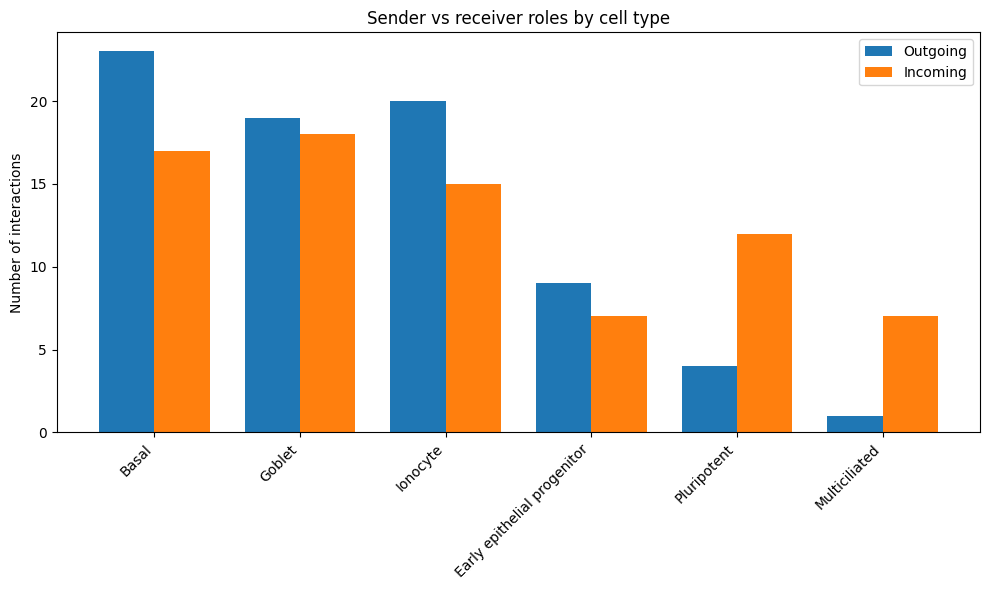

In [32]:
# Plot sender vs receiver roles

plot_df = hub_summary.copy()
x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["outgoing_total"], width=width, label="Outgoing")
plt.bar(x + width/2, plot_df["incoming_total"], width=width, label="Incoming")

plt.xticks(x, plot_df["celltype"], rotation=45, ha="right")
plt.ylabel("Number of interactions")
plt.title("Sender vs receiver roles by cell type")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "sender_receiver_roles_barplot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [33]:
# Step: Developmental signaling subset

developmental_genes = {
    "MDK", "BMP7", "L1CAM", "CDH1", "ERBB3",
    "LAMA5", "DAG1", "NCL", "PTPRF", "CD9", "SDC2"
}

dev_df = liana_res[
    liana_res["ligand_complex"].isin(developmental_genes) |
    liana_res["receptor_complex"].isin(developmental_genes)
].copy()

dev_df = dev_df.sort_values("magnitude_rank", ascending=True)

dev_df.to_csv(
    os.path.join(results_dir, "processed_developmental_signaling_interactions.csv"),
    index=False
)

dev_df.head(30)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair
0,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545,MDK | NCL
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK | NCL
2,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142,MDK | NCL
3,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253559,8.330219,0.035448,0.951710,0.491650,0.071662,MDK | NCL
4,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK | NCL
5,Ionocyte,Basal,MDK,NCL,2.380580,0.000,0.658427,0.220139,8.460706,0.024506,0.942484,0.404722,0.092725,MDK | NCL
6,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.000000,0.116248,MDK | NCL
8,Goblet,Basal,MDK,NCL,2.370169,0.000,0.562265,0.209209,8.372158,0.020927,0.938052,0.595157,0.142149,MDK | NCL
9,Basal,Multiciliated,MDK,NCL,1.245581,1.000,1.550217,0.181316,-12.129643,0.057698,0.961750,1.000000,0.170346,MDK | NCL
10,Early epithelial progenitor,Early epithelial progenitor,MDK,NCL,1.237667,1.000,0.467927,-0.185343,-12.794704,0.017416,0.932496,1.000000,0.200758,MDK | NCL


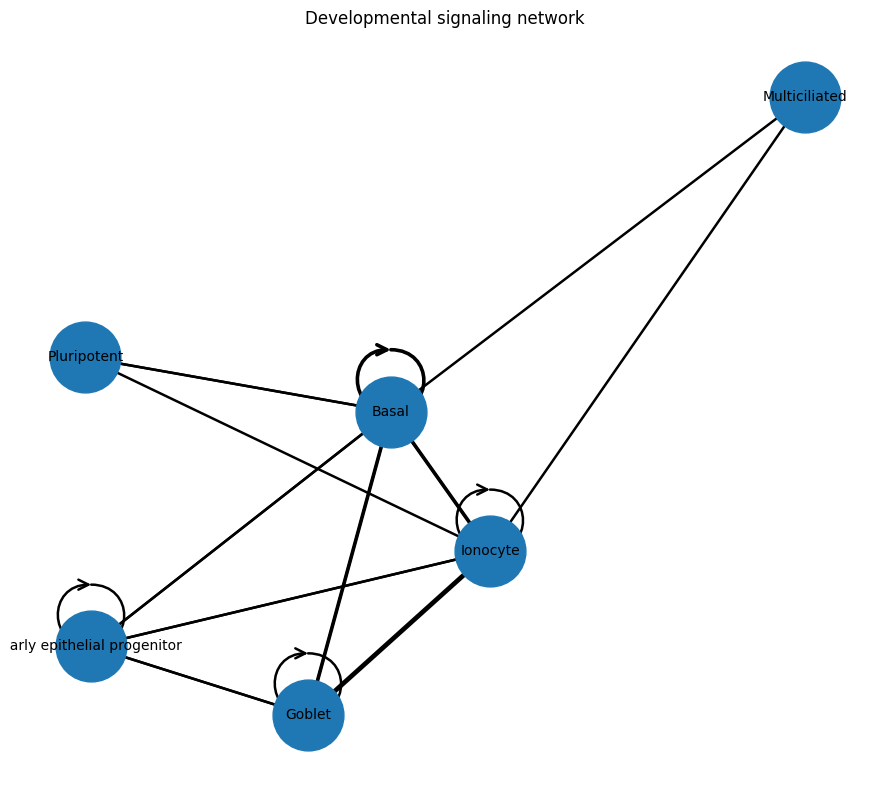

In [34]:
# Keep top developmental interactions for plotting

dev_top = dev_df.head(25).copy()

G_dev = nx.DiGraph()

for _, row in dev_top.iterrows():
    source = row["source"]
    target = row["target"]
    lr = row["lr_pair"]

    if G_dev.has_edge(source, target):
        G_dev[source][target]["weight"] += 1
        G_dev[source][target]["labels"].append(lr)
    else:
        G_dev.add_edge(source, target, weight=1, labels=[lr])

plt.figure(figsize=(9, 8))
pos = nx.spring_layout(G_dev, seed=42)

edge_weights = [G_dev[u][v]["weight"] for u, v in G_dev.edges()]
edge_widths = [1 + w * 0.8 for w in edge_weights]

nx.draw_networkx_nodes(G_dev, pos, node_size=2600)
nx.draw_networkx_labels(G_dev, pos, font_size=10)
nx.draw_networkx_edges(
    G_dev, pos,
    width=edge_widths,
    arrows=True,
    arrowstyle="->",
    arrowsize=18
)

plt.title("Developmental signaling network")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "developmental_signaling_network.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
# Step: Cell-type specific tables

celltypes_of_interest = [
    "Basal",
    "Goblet",
    "Ionocyte",
    "Early epithelial progenitor"
]

for ct in celltypes_of_interest:
    sender_df = (
        liana_res[liana_res["source"] == ct]
        .sort_values("magnitude_rank", ascending=True)
        .copy()
    )
    receiver_df = (
        liana_res[liana_res["target"] == ct]
        .sort_values("magnitude_rank", ascending=True)
        .copy()
    )

    sender_df.to_csv(
        os.path.join(results_dir, f"{ct.replace(' ', '_')}_as_sender.csv"),
        index=False
    )
    receiver_df.to_csv(
        os.path.join(results_dir, f"{ct.replace(' ', '_')}_as_receiver.csv"),
        index=False
    )

print("Saved cell-type specific sender and receiver tables.")

Saved cell-type specific sender and receiver tables.


In [36]:
basal_sender = pd.read_csv(os.path.join(results_dir, "Basal_as_sender.csv"))
basal_sender.head(20)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair
0,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.818034,12.608398,0.220204,0.980048,0.016043,0.001545,MDK | NCL
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK | NCL
2,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379132,-8.516525,0.108186,0.971775,0.579032,0.053142,MDK | NCL
3,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK | NCL
4,Basal,Multiciliated,MDK,NCL,1.245581,1.000,1.550217,0.181316,-12.129643,0.057698,0.961750,1.000000,0.170346,MDK | NCL
5,Basal,Pluripotent,MDK,NCL,1.208449,1.000,1.455086,0.167438,-11.049876,0.054157,0.960568,1.000000,0.233302,MDK | NCL
6,Basal,Basal,LAMA5,DAG1,0.132023,0.000,0.017153,0.392970,0.384748,0.523257,0.725640,0.063718,0.341424,LAMA5 | DAG1
7,Basal,Pluripotent,CALM1,HMMR,0.405621,0.000,0.088728,0.548087,1.102697,0.265198,0.857455,0.050944,0.437382,CALM1 | HMMR
8,Basal,Ionocyte,CDH1,PTPRF,0.319450,0.000,0.062962,0.409314,0.784119,0.110782,0.835180,0.050944,0.543358,CDH1 | PTPRF
9,Basal,Basal,L1CAM,CD9,0.411121,0.000,0.133729,0.293064,0.415660,0.043451,0.880738,0.373081,0.543358,L1CAM | CD9


In [37]:
# Step: Selected biologically relevant pairs

selected_pairs = [
    ("Early epithelial progenitor", "Goblet"),
    ("Basal", "Goblet"),
    ("Basal", "Ionocyte"),
    ("Goblet", "Goblet"),
    ("Ionocyte", "Goblet")
]

selected_tables = []

for s, t in selected_pairs:
    sub = (
        liana_res[
            (liana_res["source"] == s) &
            (liana_res["target"] == t)
        ]
        .sort_values("magnitude_rank", ascending=True)
        .copy()
    )
    sub["selected_pair"] = f"{s} -> {t}"
    selected_tables.append(sub)

selected_df = pd.concat(selected_tables, ignore_index=True)

selected_df.to_csv(
    os.path.join(results_dir, "processed_selected_pairs_detailed.csv"),
    index=False
)

selected_df.head(30)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,lr_pair,selected_pair
0,Early epithelial progenitor,Goblet,MDK,NCL,1.490315,0.836,0.572127,-0.090939,-9.249641,0.021294,0.938555,1.000000,0.116248,MDK | NCL,Early epithelial progenitor -> Goblet
1,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473536,-4.971462,0.132277,0.974405,0.453758,0.037246,MDK | NCL,Basal -> Goblet
2,Basal,Goblet,CDH1,PTPRF,0.318167,0.000,0.061635,0.404280,0.791090,0.108446,0.833709,0.050944,0.582155,CDH1 | PTPRF,Basal -> Goblet
3,Basal,Goblet,L1CAM,CD9,0.593472,0.000,0.215153,0.543816,1.443353,0.069908,0.903541,0.110727,0.960927,L1CAM | CD9,Basal -> Goblet
4,Basal,Goblet,L1CAM,ERBB3,0.169431,0.000,0.025809,0.580489,0.392217,0.161657,0.764389,0.050944,1.000000,L1CAM | ERBB3,Basal -> Goblet
5,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301263,-8.711403,0.088310,0.968854,1.000000,0.071662,MDK | NCL,Basal -> Ionocyte
6,Basal,Ionocyte,CDH1,PTPRF,0.319450,0.000,0.062962,0.409314,0.784119,0.110782,0.835180,0.050944,0.543358,CDH1 | PTPRF,Basal -> Ionocyte
7,Basal,Ionocyte,MDK,TSPAN1,0.725827,0.000,0.218609,0.800729,2.683855,0.326489,0.904233,0.011638,0.708558,MDK | TSPAN1,Basal -> Ionocyte
8,Basal,Ionocyte,L1CAM,CD9,0.587696,0.000,0.212574,0.535873,0.971731,0.069069,0.903014,0.125720,0.906548,L1CAM | CD9,Basal -> Ionocyte
9,Goblet,Goblet,MDK,NCL,1.448077,0.981,0.337755,-0.135290,-9.207702,0.012571,0.921484,1.000000,0.342907,MDK | NCL,Goblet -> Goblet


In [ ]:
### EXTRA ###

In [47]:
# Step: Candidate prioritization table

candidate_table = top_global[[
    "source", "target", "ligand_complex", "receptor_complex",
    "lr_pair", "magnitude_rank", "specificity_rank"
]].copy()

candidate_table["priority_reason"] = ""

candidate_table.loc[
    candidate_table["ligand_complex"].isin(["MDK", "BMP7", "L1CAM", "CDH1", "LAMA5"]),
    "priority_reason"
] += "known developmental/epithelial ligand; "

candidate_table.loc[
    candidate_table["receptor_complex"].isin(["NCL", "ERBB3", "SDC2", "CD9", "PTPRF"]),
    "priority_reason"
] += "known signaling receptor; "

candidate_table.loc[
    candidate_table["source"].isin(["Basal", "Early epithelial progenitor"]),
    "priority_reason"
] += "comes from likely regulatory sender cell; "

candidate_table.loc[
    candidate_table["target"].isin(["Goblet", "Ionocyte"]),
    "priority_reason"
] += "targets functional epithelial lineage; "

candidate_table.to_csv(
    os.path.join(results_dir, "processed_prioritized_lr_candidates.csv"),
    index=False
)

candidate_table.head(35)

,source,target,ligand_complex,receptor_complex,lr_pair,magnitude_rank,specificity_rank,priority_reason
0,Basal,Basal,MDK,NCL,MDK | NCL,0.001545,0.016043,known developmental/epithelial ligand; known s...
1,Basal,Goblet,MDK,NCL,MDK | NCL,0.037246,0.453758,known developmental/epithelial ligand; known s...
2,Basal,Early epithelial progenitor,MDK,NCL,MDK | NCL,0.053142,0.579032,known developmental/epithelial ligand; known s...
3,Early epithelial progenitor,Basal,MDK,NCL,MDK | NCL,0.071662,0.491650,known developmental/epithelial ligand; known s...
4,Basal,Ionocyte,MDK,NCL,MDK | NCL,0.071662,1.000000,known developmental/epithelial ligand; known s...
5,Ionocyte,Basal,MDK,NCL,MDK | NCL,0.092725,0.404722,known developmental/epithelial ligand; known s...
6,Early epithelial progenitor,Goblet,MDK,NCL,MDK | NCL,0.116248,1.000000,known developmental/epithelial ligand; known s...
7,Pluripotent,Goblet,ARF6,SMAP1,ARF6 | SMAP1,0.116870,0.160222,targets functional epithelial lineage;
8,Goblet,Basal,MDK,NCL,MDK | NCL,0.142149,0.595157,known developmental/epithelial ligand; known s...
9,Basal,Multiciliated,MDK,NCL,MDK | NCL,0.170346,1.000000,known developmental/epithelial ligand; known s...


In [48]:
# Step: Receptor-focused druggable table

druggable_receptors = ["NCL", "ERBB3", "SDC2", "CD9", "PTPRF"]

druggable_df = candidate_table[
    candidate_table["receptor_complex"].isin(druggable_receptors)
].copy()

druggable_df = druggable_df.sort_values("magnitude_rank", ascending=True)

druggable_df.to_csv(
    os.path.join(results_dir, "processed_druggable_receptor_candidates.csv"),
    index=False
)

druggable_df.head(35)

,source,target,ligand_complex,receptor_complex,lr_pair,magnitude_rank,specificity_rank,priority_reason
0,Basal,Basal,MDK,NCL,MDK | NCL,0.001545,0.016043,known developmental/epithelial ligand; known s...
1,Basal,Goblet,MDK,NCL,MDK | NCL,0.037246,0.453758,known developmental/epithelial ligand; known s...
2,Basal,Early epithelial progenitor,MDK,NCL,MDK | NCL,0.053142,0.579032,known developmental/epithelial ligand; known s...
3,Early epithelial progenitor,Basal,MDK,NCL,MDK | NCL,0.071662,0.491650,known developmental/epithelial ligand; known s...
4,Basal,Ionocyte,MDK,NCL,MDK | NCL,0.071662,1.000000,known developmental/epithelial ligand; known s...
5,Ionocyte,Basal,MDK,NCL,MDK | NCL,0.092725,0.404722,known developmental/epithelial ligand; known s...
6,Early epithelial progenitor,Goblet,MDK,NCL,MDK | NCL,0.116248,1.000000,known developmental/epithelial ligand; known s...
8,Goblet,Basal,MDK,NCL,MDK | NCL,0.142149,0.595157,known developmental/epithelial ligand; known s...
9,Basal,Multiciliated,MDK,NCL,MDK | NCL,0.170346,1.000000,known developmental/epithelial ligand; known s...
10,Early epithelial progenitor,Early epithelial progenitor,MDK,NCL,MDK | NCL,0.200758,1.000000,known developmental/epithelial ligand; known s...


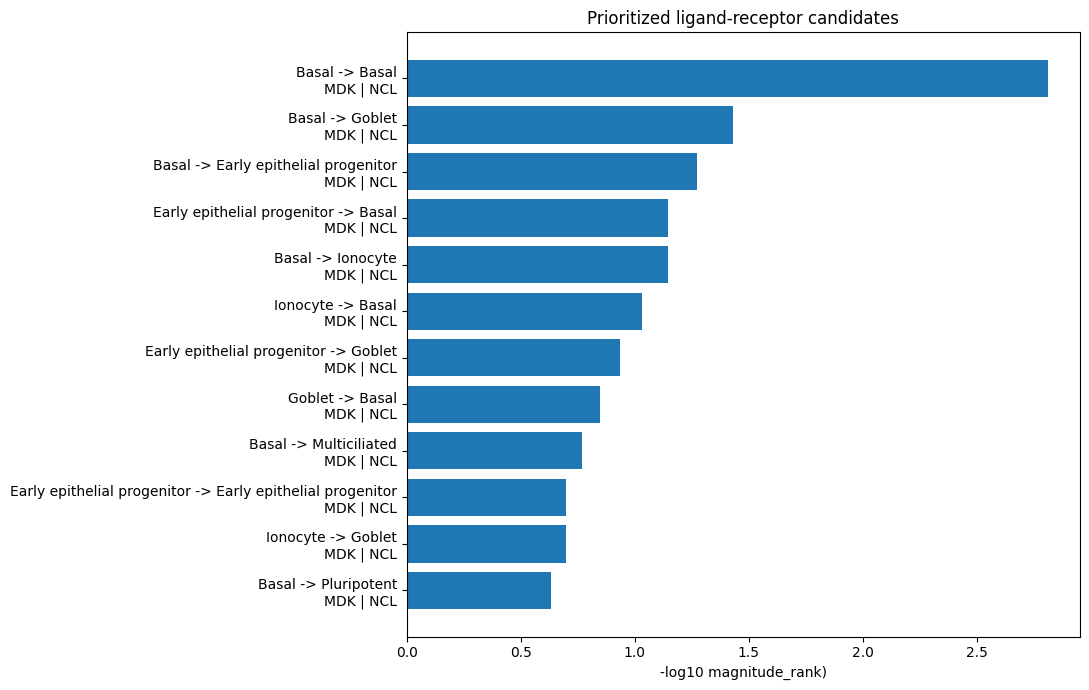

In [40]:
# Step: Plot prioritized candidate interactions

plot_df = druggable_df.head(12).copy()
plot_df["interaction_label"] = (
    plot_df["source"] + " -> " + plot_df["target"] + "\n" + plot_df["lr_pair"]
)

plt.figure(figsize=(11, 7))
plt.barh(
    plot_df["interaction_label"][::-1],
    -np.log10(plot_df["magnitude_rank"][::-1] + 1e-12)
)

plt.xlabel("-log10 magnitude_rank)")
plt.title("Prioritized ligand-receptor candidates")
plt.tight_layout()

plt.savefig(
    os.path.join(figures_dir, "prioritized_lr_candidates_barplot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [44]:
import pandas as pd

# Load the file
df = pd.read_csv("../results/processed_druggable_receptor_candidates.csv")

# Print number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 24
Columns: 8


In [41]:
# Step: Role classification

role_df = hub_summary.copy()

def classify_role(row):
    out_val = row["outgoing_total"]
    in_val = row["incoming_total"]

    if out_val > in_val * 1.3:
        return "sender-biased"
    elif in_val > out_val * 1.3:
        return "receiver-biased"
    else:
        return "balanced"

role_df["role_class"] = role_df.apply(classify_role, axis=1)

role_df.to_csv(
    os.path.join(results_dir, "processed_celltype_role_classification.csv"),
    index=False
)

role_df

,celltype,outgoing_total,incoming_total,total_signal,role_class
0,Basal,23,17,40,sender-biased
2,Goblet,19,18,37,balanced
3,Ionocyte,20,15,35,sender-biased
1,Early epithelial progenitor,9,7,16,balanced
5,Pluripotent,4,12,16,receiver-biased
4,Multiciliated,1,7,8,receiver-biased


In [42]:
# Step: Ligand frequency table

ligand_counts = (
    liana_res["ligand_complex"]
    .value_counts()
    .reset_index()
)
ligand_counts.columns = ["ligand_complex", "count"]

ligand_counts.to_csv(
    os.path.join(results_dir, "processed_ligand_frequency_table.csv"),
    index=False
)

ligand_counts.head(20)

,ligand_complex,count
0,MDK,32
1,L1CAM,21
2,CDH1,6
3,CALM1,5
4,BMP7,3
5,ARF6,2
6,LAMA5,2
7,HRG,1
8,LUM,1
9,LAMC1,1


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("adata_human_mapped_filtered_for_liana.h5ad")

# Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata)

# PCA
sc.pp.pca(adata)

# Neighbors
sc.pp.neighbors(adata)

# UMAP
sc.tl.umap(adata)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'adata_human_mapped_filtered_for_liana.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
sc.pl.violin(
    adata,
    genes_present,
    groupby="CellType",
    rotation=90
)